In [2]:
import ast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tabpfn_sbi.utils import use_style
from tabpfn_sbi.utils.plot_utils import DEFAULT_COLORS, get_task_plot_name

plt.rcParams["svg.fonttype"] = "path"

gaussian_mixture
two_moons
slcp
gaussian_linear
sir
bernoulli_glm
lotka_volterra


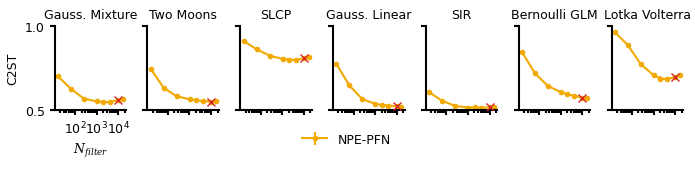

In [3]:
tasks = [
    "gaussian_mixture",
    "two_moons",
    "slcp",
    "gaussian_linear",
    "sir",
    "bernoulli_glm",
    "lotka_volterra",
]

# Read the CSV file
df = pd.read_csv("../../results/sbibm_filter_abla/summary.csv")


# Extract filter_context_size from the cfg string
def extract_filter_context_size(cfg_string):
    try:
        cfg_dict = ast.literal_eval(cfg_string)
        return cfg_dict["method"]["filter_context_size"]
    except:
        return None


df["num_simulations"] = df["cfg"].apply(extract_filter_context_size)


with use_style("pyloric"):
    fig, ax = plt.subplots(1, 7, figsize=(7, 1.8))
    for ix, ta in enumerate(tasks):
        dftemp = df[df["task"] == ta]

        c2sts = []
        c2sts_std = []
        for filter_size in [16, 64, 256, 1024, 2048, 4096, 10000, 16384]:
            df_per_filter = dftemp[dftemp["num_simulations"] == filter_size]
            seeds_mean = []
            for st in df_per_filter["value"]:
                res = ast.literal_eval(st)
                obs_mean = np.mean(res)
                seeds_mean.append(obs_mean)

            overall_mean = np.mean(seeds_mean)
            overall_std = np.std(seeds_mean)
            # print(
            #     f"Task: {ta}, Filter size: {filter_size}, C2ST: {overall_mean:.2f}, STD: {overall_std:.2f}"
            # )

            c2sts.append(overall_mean)
            c2sts_std.append(overall_std)

        ax[ix].errorbar(
            [16, 64, 256, 1024, 2048, 4096, 10000, 16384],
            c2sts,
            yerr=c2sts_std,
            marker="o",
            color=DEFAULT_COLORS["filtered_tabpfn"],
            label="NPE-PFN" if ix == 0 else None,
            zorder=1,
        )
        # plot the point at 10000 with a different marker
        ax[ix].plot(
            10000,
            c2sts[6],
            marker="x",
            markersize=6,
            color="C3",
            zorder=3,
        )
        ax[ix].set_ylim(0.5, 1.0)

        ax[ix].set_title(get_task_plot_name(ta))
        ax[ix].set_xticks([16, 64, 256, 1024, 2048, 4096, 10000, 16384])
        ax[ix].set_xticklabels([16, 64, 256, 1024, 2048, 4096, 10000, 16384])
        ax[ix].set_xscale("log")
        ax[ix].set_yticks([0.5, 1.0])
        if ix > 0:
            ax[ix].set_yticklabels([])
            ax[ix].set_xticklabels([])
        else:
            ax[ix].set_ylabel("C2ST", x=-0.18)
            ax[ix].set_xlabel(r"$N_{filter}$")

    # remove duplicate labels
    handles, labels = ax[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.30),
    )

    fig.tight_layout()
    fig.savefig("vary_filter_sizes.svg", bbox_inches="tight", transparent=True)